# Player profiles × International results — EDA & merge ideas

Explore **`data/Player_profiles`** (FIFA-style player ratings, 2022–2026) and sketch how to join it with **`data/international/results.csv`** for **World Cup match prediction**.

**Grain mismatch (important):**
- Player profiles: one row per `player_id` × `year` (club + nationality + attribute ratings).
- International results: one row per **match** (home/away teams, scores, tournament).

**Temporal mismatch (important):** ratings exist only for **2022–2026**, while `results.csv` runs from **1872** onward. You cannot honestly attach squad-strength features to pre-2022 matches unless you obtain older rating exports. Section 5.5 quantifies this and lists modeling workarounds.

There is **no direct player–match key**. The practical merge path is:
1. Roll player ratings up to **national-team strength features** by `nationality` and `year`.
2. Harmonize country names with international results (plus `former_names.csv`).
3. Attach those team features to each side of every international match (home + away).

See also: `test_2.ipynb` (match-level rolling form from results only), `player_ratings_parquet_schema.md`, and **§7** (external sources for pre-2022 ratings, FIFA rank, confederation).

## 0. Setup

In [1]:
# %pip install pandas pyarrow duckdb matplotlib seaborn

import warnings
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.2f}".format)
sns.set_theme(style="whitegrid", palette="muted")

_cwd = Path.cwd()
if (_cwd / "data" / "Player_profiles").is_dir():
    ROOT = _cwd
elif (_cwd.parent / "data" / "Player_profiles").is_dir():
    ROOT = _cwd.parent
else:
    ROOT = _cwd

PP_PATH = ROOT / "data" / "Player_profiles" / "player_ratings_2022_2026.parquet"
INTL_DIR = ROOT / "data" / "international"
RESULTS_PATH = INTL_DIR / "results.csv"
FORMER_NAMES_PATH = INTL_DIR / "former_names.csv"
FIGURES_DIR = ROOT / "results" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

con = duckdb.connect()

def duck(sql: str) -> pd.DataFrame:
    return con.execute(sql).df()

print("ROOT:", ROOT)
print("Player profiles:", PP_PATH.exists())
print("International results:", RESULTS_PATH.exists())

ROOT: /Users/rabin/Documents/courses/UBC-MDS-Soccer-Capstone-2026
Player profiles: True
International results: True


---
## 1. Player profiles — structure & coverage

In [2]:
players = pd.read_parquet(PP_PATH)
print(f"Shape: {players.shape[0]:,} rows × {players.shape[1]} columns")
print(f"Grain check — duplicates on (player_id, year):", players.duplicated(["player_id", "year"]).sum())
players.head(3)

Shape: 101,048 rows × 54 columns
Grain check — duplicates on (player_id, year): 0


,player_id,player_name,nationality,club,league,positions,primary_position,year,overall,age,height_cm,weight_kg,pace,shooting,passing_rating,dribbling,defending,physical,dribbling_attr,acceleration,sprint_speed,finishing,shot_power,long_shots,volleys,...,short_passing,long_passing,curve,agility,balance,reactions,ball_control,composure,positioning,interceptions,heading_accuracy,defensive_awareness,standing_tackle,sliding_tackle,jumping,stamina,strength,aggression,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes,world_cup_squad_tournament_year,was_world_cup_squad_member
0,1703,Ante Budimir,Croatia,CA Osasuna,Spain Primera División,ST,ST,2022,77,31,190,75,64,74,45,65,40,73,65,61,68,81,78,71,70,...,68,30,44,56,33,72,79,72,80,24,84,29,35,27,65,68,83,77,<NA>,<NA>,<NA>,<NA>,<NA>,2022,True
1,3019,Granit Xhaka,Switzerland,Arsenal,England Premier League,"CDM, CM",CDM,2022,79,29,185,82,50,65,81,66,68,71,66,48,52,50,90,75,50,...,84,84,76,49,61,73,80,67,62,71,62,71,68,68,33,82,79,91,<NA>,<NA>,<NA>,<NA>,<NA>,2022,True
2,2961,Domagoj Vida,Croatia,Beşiktaş,Turkey Süper Lig,CB,CB,2022,77,33,184,76,74,41,57,65,79,83,65,74,74,41,54,22,36,...,62,60,44,64,63,72,62,75,43,79,79,81,77,78,87,82,80,82,<NA>,<NA>,<NA>,<NA>,<NA>,2022,True


In [3]:
profile_cols = [
    "player_id", "player_name", "nationality", "club", "league",
    "positions", "primary_position", "year", "overall", "age",
    "was_world_cup_squad_member", "world_cup_squad_tournament_year",
]
players[profile_cols].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
player_id,101048.00,NaN,NaN,NaN,18785.09,11620.24,1.00,9076.00,17485.50,27695.25,44373.00
player_name,101048,43983,,267,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nationality,101048,182,England,8797,NaN,NaN,NaN,NaN,NaN,NaN,NaN
club,101048,949,NG - FA,446,NaN,NaN,NaN,NaN,NaN,NaN,NaN
league,101048,41,Argentina Primera División,4728,NaN,NaN,NaN,NaN,NaN,NaN,NaN
positions,101048,1426,CB,13242,NaN,NaN,NaN,NaN,NaN,NaN,NaN
primary_position,101048,15,CB,18002,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,101048.00,NaN,NaN,NaN,2023.95,1.45,2022.00,2023.00,2024.00,2025.00,2026.00
overall,101048.00,NaN,NaN,NaN,65.44,6.98,45.00,61.00,65.00,70.00,92.00
age,100781.00,<NA>,<NA>,<NA>,25.31,4.88,16.00,21.00,25.00,29.00,55.00


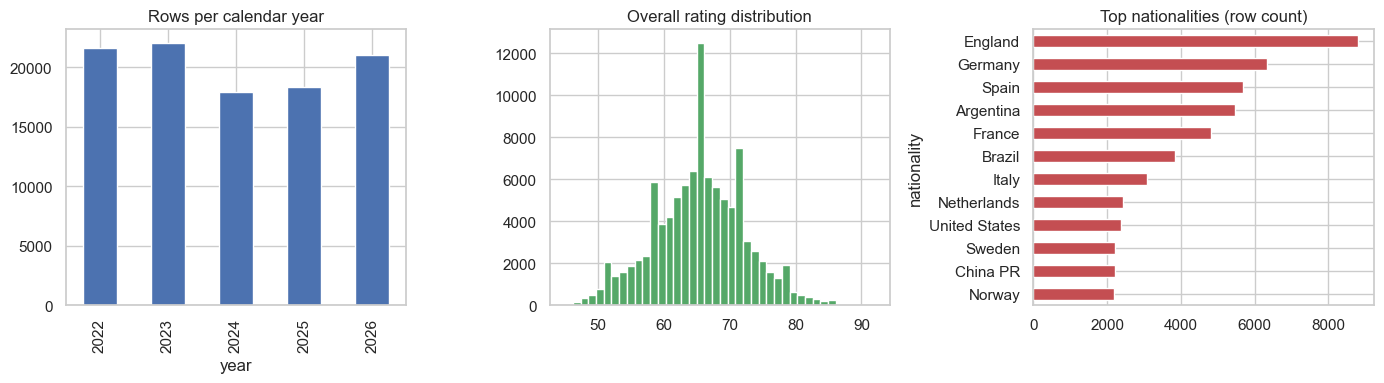

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

players["year"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Rows per calendar year")
axes[0].set_xlabel("year")

players["overall"].hist(bins=40, ax=axes[1], color="#55A868")
axes[1].set_title("Overall rating distribution")

top_nat = players["nationality"].value_counts().head(12)
top_nat.plot(kind="barh", ax=axes[2], color="#C44E52")
axes[2].set_title("Top nationalities (row count)")
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "player_profiles_coverage.png", dpi=120, bbox_inches="tight")
plt.show()

In [5]:
pos = players["primary_position"].value_counts()
print(pos)

rating_block = ["pace", "shooting", "passing_rating", "dribbling", "defending", "physical"]
players.groupby("primary_position")[rating_block + ["overall"]].mean().round(1)

primary_position
CB     18002
ST     14031
CM     12016
GK     11263
CDM     8128
RB      7050
LB      6799
CAM     5894
LM      5489
RM      5489
RW      2369
LW      2326
RWB      872
LWB      868
CF       452
Name: count, dtype: int64


,pace,shooting,passing_rating,dribbling,defending,physical,overall
primary_position,,,,,,,
CAM,69.50,60.00,65.10,68.20,43.60,57.60,66.00
CB,59.70,37.40,51.90,55.30,65.40,70.10,65.90
CDM,61.90,52.00,64.20,64.00,62.80,68.60,66.50
CF,75.10,65.40,64.50,71.20,38.60,60.10,68.90
CM,65.80,56.70,66.00,66.30,57.00,64.00,64.90
GK,34.80,17.60,31.30,34.60,13.60,42.10,63.90
LB,72.50,46.90,56.10,63.70,60.30,65.30,65.50
LM,76.40,59.10,59.70,67.30,39.70,57.90,65.80
LW,76.80,60.30,59.20,67.80,35.60,56.50,65.90


### 1.1 World Cup squad flag (2022)

The mart includes `was_world_cup_squad_member` and `world_cup_squad_tournament_year`. In the current export, squad flags are populated for **2022** only (~480 players across 32 nations). This is useful for **validating** team-strength aggregates against known WC participants, but **not** a join key to individual matches.

In [6]:
wc = players[players["was_world_cup_squad_member"]].copy()
print(f"WC squad rows: {len(wc):,} | nations: {wc['nationality'].nunique()}")
print(wc["world_cup_squad_tournament_year"].value_counts())

wc_2022_team = (
    wc[wc["world_cup_squad_tournament_year"] == 2022]
    .groupby("nationality")
    .agg(squad_size=("player_id", "count"), mean_overall=("overall", "mean"))
    .sort_values("mean_overall", ascending=False)
)
wc_2022_team.head(10)

WC squad rows: 480 | nations: 28
world_cup_squad_tournament_year
2022    480
Name: count, dtype: Int64


,squad_size,mean_overall
nationality,,
Spain,1,86.00
Portugal,1,83.00
England,25,82.52
France,25,82.04
Germany,18,81.06
Argentina,21,80.76
Belgium,22,80.14
Uruguay,23,77.70
Croatia,23,77.65


---
## 2. International results — structure & World Cup slice

In [7]:
results = pd.read_csv(RESULTS_PATH, parse_dates=["date"])
former_names = pd.read_csv(FORMER_NAMES_PATH, parse_dates=["start_date", "end_date"])

print(f"Matches: {len(results):,}")
print(f"Date range: {results['date'].min().date()} → {results['date'].max().date()}")
print(f"Distinct teams: {pd.concat([results['home_team'], results['away_team']]).nunique()}")
results.head(3)

Matches: 49,328
Date range: 1872-11-30 → 2026-06-27
Distinct teams: 336


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.00,0.00,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.00,2.00,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.00,1.00,Friendly,Glasgow,Scotland,False


In [8]:
completed = results.dropna(subset=["home_score", "away_score"]).copy()
scheduled = results[results["home_score"].isna() | results["away_score"].isna()]
print(f"Completed: {len(completed):,} | Scheduled / missing scores: {len(scheduled):,}")

wc_mask = results["tournament"].str.contains("World Cup", case=False, na=False)
wc_matches = results[wc_mask].copy()
print(f"World Cup labelled matches: {len(wc_matches):,}")
print(wc_matches["tournament"].value_counts().head(8))

Completed: 49,256 | Scheduled / missing scores: 72
World Cup labelled matches: 9,868
tournament
FIFA World Cup qualification      8771
FIFA World Cup                    1036
Viva World Cup                      60
CONIFA World Cup qualification       1
Name: count, dtype: int64


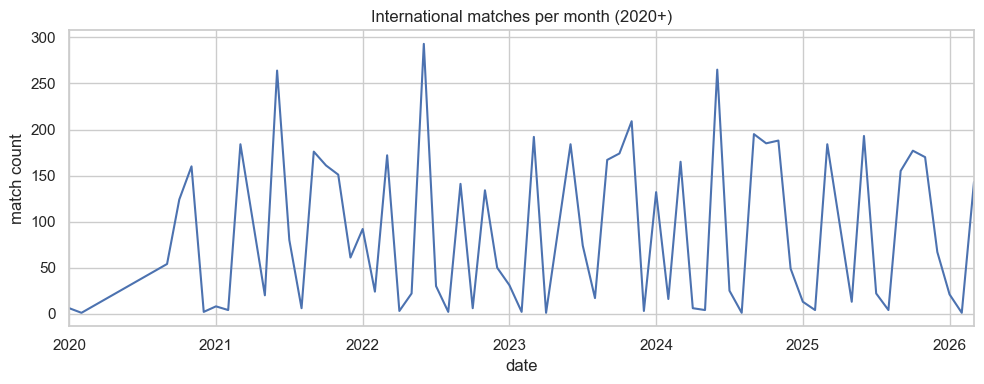

In [9]:
recent = completed[completed["date"] >= "2020-01-01"]
fig, ax = plt.subplots(figsize=(10, 4))
recent.groupby(recent["date"].dt.to_period("M")).size().plot(ax=ax, color="#4C72B0")
ax.set_title("International matches per month (2020+)")
ax.set_ylabel("match count")
plt.tight_layout()
plt.show()

---
## 3. Harmonizing country names

Player `nationality` labels (182) do not exactly match international team names (336). Most FIFA nations overlap after a small **manual alias table**. Use `former_names.csv` when aggregating historical results (e.g. Czechoslovakia → Czech Republic for post-split eras).

Teams in international data but **without** any rated players (e.g. American Samoa) will not get squad-strength features — model those with form-only baselines or league-average imputation.

In [10]:
NATIONALITY_TO_INTL_TEAM = {
    "Republic of Korea": "South Korea",
    "Korea DPR": "North Korea",
    "Türkiye": "Turkey",
    "Czechia": "Czech Republic",
    "Bosnia & Herzegovina": "Bosnia and Herzegovina",
    "Guinea Bissau": "Guinea-Bissau",
    "Antigua & Barbuda": "Antigua and Barbuda",
    "Trinidad & Tobago": "Trinidad and Tobago",
    "St Kitts Nevis": "Saint Kitts and Nevis",
    "St Lucia": "Saint Lucia",
    "St Vincent Grenadine": "Saint Vincent and the Grenadines",
    "Central African Rep.": "Central African Republic",
    "São Tomé & Príncipe": "São Tomé and Príncipe",
    "Chinese Taipei": "Taiwan",
}

intl_teams = set(pd.concat([results["home_team"], results["away_team"]]))

players_h = players.copy()
players_h["intl_team"] = players_h["nationality"].replace(NATIONALITY_TO_INTL_TEAM)

pp_teams = set(players_h["intl_team"].dropna())
overlap = pp_teams & intl_teams
only_pp = sorted(pp_teams - intl_teams)
only_intl = sorted(intl_teams - pp_teams)

print(f"Player-profile nations (mapped): {len(pp_teams)}")
print(f"International teams: {len(intl_teams)}")
print(f"Overlap after mapping: {len(overlap)}")
print("Still only in profiles:", only_pp)
print("Sample intl teams without profiles:", only_intl[:20])

Player-profile nations (mapped): 182
International teams: 336
Overlap after mapping: 182
Still only in profiles: []
Sample intl teams without profiles: ['Abkhazia', 'Alderney', 'Ambazonia', 'American Samoa', 'Andalusia', 'Anguilla', 'Arameans Suryoye', 'Artsakh', 'Aruba', 'Asturias', 'Aymara', 'Bahamas', 'Barawa', 'Basque Country', 'Biafra', 'Bonaire', 'Botswana', 'British Virgin Islands', 'Brittany', 'Brunei']


---
## 4. Team-level features from player ratings

Aggregate to **one row per (`intl_team`, `year`)**. Suggested features for modeling:

| Feature | Rationale |
|---|---|
| `top11_overall_mean` | Proxy for starting XI quality (sort by `overall`, take top 11) |
| `top11_*_mean` | Position-block strength (pace, shooting, defending, …) |
| `squad_depth` | Count of players with `overall` ≥ threshold (e.g. 75) |
| `mean_age_top11` | Experience vs youth |
| `gk_overall_mean` | Top goalkeeper overall (if any `GK`) |
| `wc_squad_share` | Share flagged `was_world_cup_squad_member` (when available) |

For a match in year *Y*, attach features from year *Y* (or *Y−1* if you want strictly pre-tournament snapshots).

In [11]:
RATING_BLOCK = ["pace", "shooting", "passing_rating", "dribbling", "defending", "physical"]


def top_n_mean(s: pd.Series, n: int = 11) -> float:
    s = s.dropna()
    if s.empty:
        return np.nan
    return s.nlargest(min(n, len(s))).mean()


def build_team_strength(df: pd.DataFrame, year: int | None = None) -> pd.DataFrame:
    d = df.copy()
    if year is not None:
        d = d[d["year"] == year]

    def _agg_group(g: pd.DataFrame) -> pd.Series:
        row = {
            "n_players": g["player_id"].nunique(),
            "mean_overall": g["overall"].mean(),
            "top11_overall": top_n_mean(g["overall"], 11),
            "depth_75": (g["overall"] >= 75).sum(),
            "wc_squad_n": g["was_world_cup_squad_member"].sum(),
        }
        for col in RATING_BLOCK:
            row[f"top11_{col}"] = top_n_mean(g[col], 11)
        gk = g.loc[g["primary_position"] == "GK", "overall"]
        row["gk_overall_max"] = gk.max() if len(gk) else np.nan
        return pd.Series(row)

    return d.groupby(["intl_team", "year"], as_index=False).apply(_agg_group)


team_strength = build_team_strength(players_h)
team_strength.sort_values(["year", "top11_overall"], ascending=[True, False]).groupby("year").head(8)

,intl_team,year,n_players,mean_overall,top11_overall,depth_75,wc_squad_n,top11_pace,top11_shooting,top11_passing_rating,top11_dribbling,top11_defending,top11_physical,gk_overall_max
275,Germany,2022,1322.00,65.39,87.00,102.00,18.00,91.82,82.00,84.82,84.09,83.00,83.73,90.00
255,France,2022,1043.00,67.27,86.91,174.00,25.00,92.45,82.73,83.36,86.45,82.27,83.91,87.00
92,Brazil,2022,970.00,70.66,86.73,200.00,0.00,91.91,80.36,81.91,85.55,84.09,84.91,89.00
686,Spain,2022,1210.00,68.87,85.64,242.00,1.00,90.73,82.18,86.55,85.27,83.09,83.18,87.00
588,Portugal,2022,406.00,69.39,85.55,80.00,1.00,90.18,81.45,83.45,85.73,80.64,82.82,82.00
222,England,2022,2063.00,62.67,85.18,129.00,25.00,91.36,80.27,83.45,84.00,81.00,83.55,81.00
28,Argentina,2022,1119.00,67.94,85.09,129.00,21.00,88.82,82.09,83.64,86.36,79.64,83.82,84.00
370,Italy,2022,383.00,69.44,85.00,87.00,0.00,88.91,80.09,84.09,84.91,82.09,81.82,88.00
93,Brazil,2023,815.00,71.11,86.55,204.00,0.00,91.64,80.27,81.82,85.82,84.18,84.27,89.00
256,France,2023,1042.00,67.17,86.45,147.00,0.00,91.73,82.91,83.45,86.45,82.82,83.36,87.00


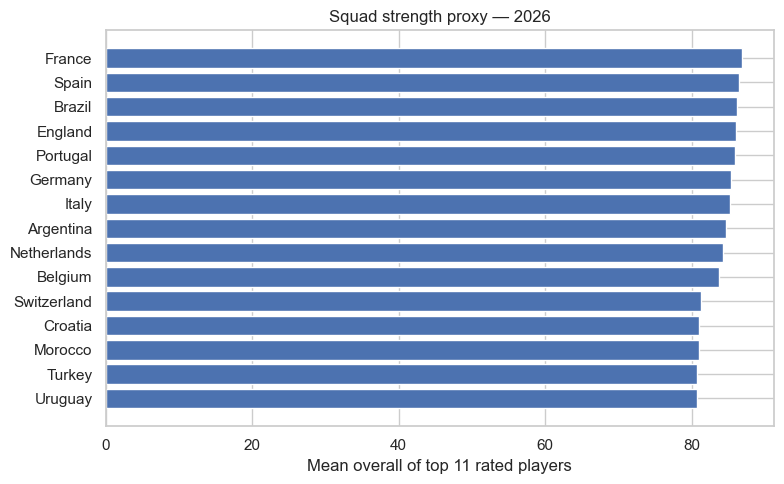

In [12]:
y = 2026
top26 = team_strength[team_strength["year"] == y].nlargest(15, "top11_overall")

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top26["intl_team"], top26["top11_overall"], color="#4C72B0")
ax.invert_yaxis()
ax.set_xlabel("Mean overall of top 11 rated players")
ax.set_title(f"Squad strength proxy — {y}")
plt.tight_layout()
plt.savefig(FIGURES_DIR / f"team_strength_top11_{y}.png", dpi=120, bbox_inches="tight")
plt.show()

---
## 5. Prototype merge: match-level modeling frame

Below we build a **long** table (one row per team per match) and left-join squad strength on `(team, match_year)`.

Combine with rolling form features from `test_2.ipynb` (goals for/against, Elo, win rate) for a full World Cup model.

In [13]:
def matches_to_long(df: pd.DataFrame) -> pd.DataFrame:
    base = df.assign(match_year=df["date"].dt.year)
    home = base.rename(
        columns={
            "home_team": "team",
            "away_team": "opponent",
            "home_score": "goals_for",
            "away_score": "goals_against",
        }
    ).assign(is_home=True)
    away = base.rename(
        columns={
            "away_team": "team",
            "home_team": "opponent",
            "away_score": "goals_for",
            "home_score": "goals_against",
        }
    ).assign(is_home=False)
    cols = [
        "date", "match_year", "team", "opponent", "is_home",
        "goals_for", "goals_against", "tournament", "city", "country", "neutral",
    ]
    out = pd.concat([home[cols], away[cols]], ignore_index=True)
    out["won"] = (out["goals_for"] > out["goals_against"]).astype("Int64")
    return out.sort_values(["date", "team"]).reset_index(drop=True)


long_matches = matches_to_long(completed)
strength_cols = ["top11_overall", "top11_pace", "top11_shooting", "top11_defending", "depth_75", "gk_overall_max"]

team_feats = team_strength.rename(columns={"intl_team": "team"})
merged = long_matches.merge(
    team_feats[["team", "year"] + strength_cols],
    left_on=["team", "match_year"],
    right_on=["team", "year"],
    how="left",
).drop(columns=["year"])

coverage = merged["top11_overall"].notna().mean()
print(f"Rows: {len(merged):,} | Squad-strength join coverage: {coverage:.1%}")
merged.dropna(subset=["top11_overall"]).head(8)

Rows: 98,512 | Squad-strength join coverage: 7.3%


,date,match_year,team,opponent,is_home,goals_for,goals_against,tournament,city,country,neutral,won,top11_overall,top11_pace,top11_shooting,top11_defending,depth_75,gk_overall_max
89670,2022-01-01,2022,Indonesia,Thailand,False,2.00,2.00,AFF Championship,Kallang,Singapore,True,0,56.00,58.00,26.00,57.00,0.00,NaN
89671,2022-01-01,2022,Thailand,Indonesia,True,2.00,2.00,AFF Championship,Kallang,Singapore,True,0,63.43,65.29,48.57,40.14,0.00,65.00
89672,2022-01-02,2022,Burkina Faso,Gabon,False,3.00,0.00,Friendly,Dubai,United Arab Emirates,True,1,70.55,78.82,60.09,58.64,2.00,73.00
89673,2022-01-02,2022,Gabon,Burkina Faso,True,0.00,3.00,Friendly,Dubai,United Arab Emirates,True,0,71.27,74.73,61.27,62.45,3.00,NaN
89674,2022-01-02,2022,Sudan,Zimbabwe,True,0.00,0.00,Friendly,Yaoundé,Cameroon,True,0,61.67,81.00,55.67,28.67,0.00,NaN
89675,2022-01-02,2022,Zimbabwe,Sudan,False,0.00,0.00,Friendly,Yaoundé,Cameroon,True,0,69.55,76.82,58.73,54.64,1.00,NaN
89676,2022-01-03,2022,Guinea,Rwanda,False,0.00,3.00,Friendly,Kigali,Rwanda,False,0,72.91,83.45,66.45,68.64,3.00,66.00
89678,2022-01-04,2022,Gabon,Mauritania,False,1.00,1.00,Friendly,Dubai,United Arab Emirates,True,0,71.27,74.73,61.27,62.45,3.00,NaN


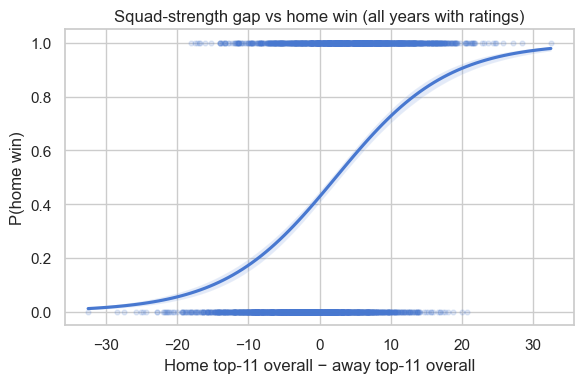

Correlation (point-biserial approx.): 0.4230308521581818


In [14]:
# Opponent strength differential (home perspective on original match grain)
wide = completed.copy()
wide["match_year"] = wide["date"].dt.year
ts = team_strength.rename(columns={"intl_team": "team"})

wide = wide.merge(
    ts[["team", "year", "top11_overall"]].rename(
        columns={"team": "home_team", "top11_overall": "home_top11", "year": "match_year"}
    ),
    on=["home_team", "match_year"],
    how="left",
)
wide = wide.merge(
    ts[["team", "year", "top11_overall"]].rename(
        columns={"team": "away_team", "top11_overall": "away_top11", "year": "match_year"}
    ),
    on=["away_team", "match_year"],
    how="left",
)
wide["top11_diff"] = wide["home_top11"] - wide["away_top11"]

sample = wide.dropna(subset=["top11_diff", "home_score", "away_score"]).copy()
sample["home_win"] = (sample["home_score"] > sample["away_score"]).astype(int)

fig, ax = plt.subplots(figsize=(6, 4))
sns.regplot(data=sample, x="top11_diff", y="home_win", logistic=True, scatter_kws={"alpha": 0.15, "s": 12}, ax=ax)
ax.set_xlabel("Home top-11 overall − away top-11 overall")
ax.set_ylabel("P(home win)")
ax.set_title("Squad-strength gap vs home win (EDA only — see §6.5 for 3-way outcome)")
plt.tight_layout()
plt.show()

print("Correlation (point-biserial, binary home win):", sample[["top11_diff", "home_win"]].corr().iloc[0, 1])
print("(Draws are coded as home_loss=0; use outcome_label for modeling.)")

---
## 5.5 Temporal coverage — no player ratings before 2022

International results give ~49k completed matches back to 1872. Player profiles cover **five calendar years only** (`2022`–`2026`). Even if you cut training at 2000 or 2010, **squad-strength features are still missing** until 2022.

**Do not** join 2026 ratings onto 1998 World Cup rows and train on that — that is leakage and fiction.

Practical options:
1. **Hybrid (recommended):** train Elo / rolling-form on full history (`test_2.ipynb`); add `top11_overall` etc. only for **2022+** rows or only at **2026 inference**.
2. **Recent-only training:** fit a model on ~4.4k matches from 2022+ where both features and ratings exist (smaller, but consistent).
3. **Missing-indicator:** keep all history; set rating columns to null before 2022 and add `has_squad_ratings` (tree models handle this; linear models need care).
4. **Stacked models:** base predictor = Elo/form; residual correction from ratings when available.
5. **Source more history:** extend the upstream mart export or use public backfills documented in **§7.1**.

For **World Cup 2026 prediction**, you only need ratings for qualified nations in 2025/2026 — the gap hurts **training**, not **scoring future fixtures**.

In [ ]:
completed["match_year"] = completed["date"].dt.year
rated_years = set(players["year"].unique())

rows = []
for start in [1872, 1990, 2000, 2010, 2018, 2022]:
    sub = completed[completed["match_year"] >= start]
    rated = sub[sub["match_year"].isin(rated_years)]
    rows.append({
        "from_year": start,
        "n_matches": len(sub),
        "n_with_rating_year": len(rated),
        "pct_with_ratings": round(100 * len(rated) / len(sub), 1),
    })

coverage_tbl = pd.DataFrame(rows)
coverage_tbl

wc = completed[completed["tournament"].str.contains("FIFA World Cup", case=False, na=False)]
print(
    f"World Cup matches: {len(wc):,} total | "
    f"{len(wc[wc['match_year'] < 2000]):,} before 2000 | "
    f"{len(wc[wc['match_year'] >= 2022]):,} from 2022+ (rating years)"
)

---
## 6. Merge strategies for World Cup prediction

### A. Recommended baseline (match outcome model)

1. **Form features** from `results.csv` only (as in `test_2.ipynb`): rolling goals, points, Elo, days since last match.
2. **Squad-strength features** from this notebook: `home_top11`, `away_top11`, `top11_diff`, block ratings (pace/defending), `depth_75`.
3. **Context**: `neutral`, `tournament` (World Cup / qualifier / friendly), host `country`.
4. **Target**: three-way `outcome_label` (home_win / draw / away_win) — see **§6.5**; or Poisson goals (`home_score`, `away_score`).

Train on pre-2026 international matches; validate on 2022 World Cup or recent Nations League; predict 2026 fixtures (including rows with missing scores in `results.csv`).

### B. Time alignment choices

| Choice | When to use |
|---|---|
| Same `year` as match | Simple default; ratings reflect calendar-year snapshot |
| `year - 1` for WC summer | Avoid leakage if 2026 ratings are updated mid-year |
| Closest prior year | For early-2026 friendlies before 2026 export refresh |

### C. Handling teams without player data

- **Impute** with median `top11_overall` by confederation or FIFA rank bucket.
- **Two-model**: main model for rated nations; fallback logistic/Elo for minnows.
- **Exclude** low-stakes friendlies involving unmapped teams from training.

### D. Richer joins (future work)

- **`goalscorers.csv`**: scorer names → fuzzy match to `player_name` for finishing talent / star-player flags.
- **StatsBomb** (`player_club_vs_national.ipynb`): event-based form for nations covered in open data.
- **Polymarket** (`eda_exploration.ipynb`): market-implied win probabilities as a benchmark or feature.
- **`former_names.csv`**: rewrite historical `team` to current name before rolling aggregates.

### E. Example modeling row (wide, one match)

```text
date, home_team, away_team, tournament, neutral,
home_elo, away_elo, home_roll_pts, away_roll_pts,
home_top11_overall, away_top11_overall, top11_diff,
home_top11_shooting, away_top11_shooting,
→ home_score, away_score (or home_win)
```

### F. World Cup 2026 workflow

1. Filter `results` to WC 2026 tournament rows (scheduled + played).
2. Attach 2026 (or 2025) squad strength for each qualified nation.
3. Blend with recent qualifier form (last 12 months, same confederation opponents weighted higher).
4. Output: win/draw/loss probabilities per fixture; optional scoreline via Poisson with attack/defense derived from `top11_shooting` / `top11_defending`.

See **§6.5** for the full variable list and how to model **draws** (not just home win).

---
## 6.5 Match outcome model — variables, target, and draws

One **row per match** (wide grain). Implementation of form features lives in `test_2.ipynb` (`intl_rq4_match_modeling`); squad-strength features come from §4–5; FIFA rank/confederation from §7.

### Outcome target (do not use binary home win only)

International football has three results. In all completed matches, draws are ~**23%** (World Cup ~**21%**). A binary `home_win` (1/0) codes a draw as **home loss**, which mislabels a large share of data.

`test_2.ipynb` already builds a three-way label:

| `outcome_label` | Condition |
|-----------------|-----------|
| `home_win` | `home_score > away_score` |
| `draw` | `home_score == away_score` |
| `away_win` | `home_score < away_score` |

Scheduled fixtures (null scores) keep `outcome_label = null` for prediction only.

### How to handle draws (recommended options)

| Approach | Model | Output | Notes |
|----------|-------|--------|-------|
| **A. Multinomial logistic** (recommended start) | `sklearn` `LogisticRegression(multi_class='multinomial')` or XGBoost `multi:softprob` | P(home), P(draw), P(away) summing to 1 | Matches `outcome_label`; use class weights if draws are under-predicted |
| **B. Poisson goals** | Separate regressors for `home_score`, `away_score` (Poisson / negative binomial) | Derive scoreline matrix → P(H), P(D), P(A) | Naturally handles draws; good for betting scorelines; Dixon–Coles extension for low scores |
| **C. Two-stage** | (1) P(decisive vs draw) (2) P(home \| decisive) | Combine: P(draw), P(home)=(1−P(draw))×P(home\|decisive), etc. | Useful if draws need separate features (e.g. knockout vs group) |

**Avoid** for the main capstone model: binary logistic `home_win` only (§5 plot is illustrative). **Knockout** matches can still end drawn after extra time — filter or add `is_knockout` if you split group vs knockout later.

### Feature variables (planned)

**Identifiers / context** (from `results.csv`)

| Variable | Role |
|----------|------|
| `match_id`, `match_date` | Keys / time |
| `home_team`, `away_team` | Keys |
| `tournament` | Context (WC, qualifier, friendly) |
| `neutral` | Home advantage off when true |
| `city`, `country` | Optional host / venue |

**Form — pre-match, no leakage** (`test_2.ipynb`, rolling window `ROLL_N = 5`)

| Variable | Description |
|----------|-------------|
| `home_roll_gf`, `away_roll_gf` | Avg goals for in last 5 matches (excl. current) |
| `home_roll_ga`, `away_roll_ga` | Avg goals against |
| `home_roll_win_rate`, `away_roll_win_rate` | Win rate in last 5 (draws count as non-wins) |
| `h2h_prior_meetings` | Count of earlier meetings between the pair |

**Squad strength** (player profiles → team-year, join on match year; null before 2022 unless backfilled)

| Variable | Description |
|----------|-------------|
| `home_top11_overall`, `away_top11_overall` | Mean overall of top 11 rated players |
| `top11_diff` | `home_top11_overall − away_top11_overall` |
| `home_top11_shooting`, `away_top11_shooting` | Top-11 mean shooting (optional) |
| `home_top11_defending`, `away_top11_defending` | Top-11 mean defending (optional) |
| `home_depth_75`, `away_depth_75` | Squad depth (players with overall ≥ 75) |
| `has_squad_ratings` | 1 if both teams have rating-year data (hybrid model) |

**FIFA rank / confederation** (§7, as-of join on `rank_date ≤ match_date`)

| Variable | Description |
|----------|-------------|
| `home_fifa_rank`, `away_fifa_rank` | FIFA rank (lower = stronger) |
| `home_fifa_points`, `away_fifa_points` | FIFA points |
| `fifa_rank_diff` | `away_fifa_rank − home_fifa_rank` (positive ⇒ home stronger) |
| `home_confederation`, `away_confederation` | UEFA, CONMEBOL, … (categorical or same-confederation flag) |

**Derived diffs** (often more stable than levels)

- `roll_gf_diff` = `home_roll_gf − away_roll_gf`
- `roll_ga_diff` = `home_roll_ga − away_roll_ga` (sign: lower is better for home)
- `top11_diff`, `fifa_rank_diff` as above

### Example prediction row

```text
Features: neutral, tournament, home_roll_gf, away_roll_gf, …, top11_diff, fifa_rank_diff, …
Target (train):  outcome_label ∈ {home_win, draw, away_win}
Output (score):  P_home_win, P_draw, P_away_win  (sum to 1)
```

For **World Cup 2026**, predict the three probabilities per fixture; argmax gives the modal outcome, but reporting all three is standard (and needed for draws).

In [ ]:
def match_outcome(df: pd.DataFrame) -> pd.Series:
    return np.select(
        [df["home_score"] > df["away_score"], df["home_score"] < df["away_score"]],
        ["home_win", "away_win"],
        default="draw",
    )


outcomes = completed.assign(outcome_label=match_outcome(completed))
dist = outcomes["outcome_label"].value_counts(normalize=True).mul(100).round(1)
print("All completed international matches (%):")
print(dist.to_string())

wc = outcomes[outcomes["tournament"].str.contains("FIFA World Cup", case=False, na=False)]
print("\nFIFA World Cup matches (%):")
print(wc["outcome_label"].value_counts(normalize=True).mul(100).round(1).to_string())

fig, ax = plt.subplots(figsize=(5, 4))
dist.plot(kind="bar", ax=ax, color=["#4C72B0", "#C44E52", "#55A868"])
ax.set_ylabel("% of matches")
ax.set_title("Match outcomes (completed)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

In [15]:
wc2026 = results[results["tournament"].str.contains("FIFA World Cup", case=False, na=False)]
wc2026 = wc2026[wc2026["date"] >= "2025-01-01"]
print(f"Recent / upcoming WC-related rows: {len(wc2026)}")
if len(wc2026):
    display_cols = ["date", "home_team", "away_team", "home_score", "away_score", "tournament", "city"]
    print(wc2026[display_cols].head(12).to_string(index=False))
else:
    print("No WC 2026 rows yet — use qualifier + friendly filters when available.")

Recent / upcoming WC-related rows: 580
      date                home_team            away_team  home_score  away_score                   tournament       city
2025-03-19                 Eswatini             Cameroon        0.00        0.00 FIFA World Cup qualification   Mbombela
2025-03-19                  Liberia              Tunisia        0.00        1.00 FIFA World Cup qualification   Monrovia
2025-03-19 Central African Republic           Madagascar        1.00        4.00 FIFA World Cup qualification Casablanca
2025-03-20                 Paraguay                Chile        1.00        0.00 FIFA World Cup qualification   Asunción
2025-03-20                     Peru              Bolivia        3.00        1.00 FIFA World Cup qualification       Lima
2025-03-20                   Brazil             Colombia        2.00        1.00 FIFA World Cup qualification   Brasília
2025-03-20                     Iran United Arab Emirates        2.00        0.00 FIFA World Cup qualification     

---
## 7. External data sources — historical ratings, FIFA rank, confederation

Research notes (May 2026) for extending the modeling frame beyond `player_ratings_2022_2026.parquet` and attaching **team rank + confederation** to `results.csv`.

### 7.1 Player ratings before 2022

Your parquet is exported from an internal mart with `EXPORT_TITLE_YEARS = 2022–2026` only. **First check the warehouse** — if older game-year slugs exist, re-export with the same schema (cheapest path).

If the mart has no history, use public **FIFA video game** ratings (same *idea* as your `overall` / attribute columns, different pipeline):

| Source | Years | URL | Notes |
|--------|-------|-----|-------|
| **lbenz730/fifa_model** | 2005–2020 | [github.com/lbenz730/fifa_model](https://github.com/lbenz730/fifa_model) | `player_stats.csv` (~62 MB): `rating`, `nationality`, `year`, skill columns. Map `rating` → `overall`. |
| **Kaggle (per edition)** | ~15–22 | e.g. [FIFA 20](https://www.kaggle.com/datasets/fatehghadeer/fifa-20-player-ratings-database), [FIFA 22](https://www.kaggle.com/datasets/cashncarry/fifa-22-complete-player-dataset) | Fills **2021** gap between fifa_model (2020) and your file (2022). |
| **SoFIFA scrapers** | Per game year | e.g. [prashantghimire/sofifa-web-scraper](https://github.com/prashantghimire/sofifa-web-scraper) | Flexible; more normalization work. |
| **FIFA Index (R)** | Custom | `fifa_scraper.R` in fifa_model repo | Re-scrape [fifaindex.com](https://www.fifaindex.com/) for chosen editions. |

**Suggested backfill timeline:** 2005–2020 (fifa_model) → 2021 (Kaggle/SoFIFA) → 2022–2026 (current parquet).

**Caveats:** Game ratings ≠ mart ratings; `player_id` will not match across sources; build a unified `team_name_crosswalk` before aggregating to national-team features.

### 7.2 FIFA world ranking + confederation

Rankings and confederation are available from FIFA ranking datasets (not in `results.csv` or player profiles).

| Source | Period | Confederation? | Rank? | URL |
|--------|--------|----------------|-------|-----|
| **Dato-Futbol/fifa-ranking** | 1992 → Sep 2024 | No (in file) | Derive from `total_points` per `date` | [ranking_fifa_historical.csv](https://github.com/Dato-Futbol/fifa-ranking/blob/master/ranking_fifa_historical.csv) |
| **cnc8/fifa-world-ranking** | 1992+ | **Yes** (`UEFA`, `CONMEBOL`, …) | **Yes** | [github.com/cnc8/fifa-world-ranking](https://github.com/cnc8/fifa-world-ranking) + [Kaggle mirror](https://www.kaggle.com/cashncarry/fifaworldranking) |
| **FiveThirtyEight** | Static | **Yes** (major nations) | No | [fifa_countries_audience.csv](https://github.com/fivethirtyeight/data/blob/master/fifa/fifa_countries_audience.csv) |
| **footballdata.io** | Recent | API filter | API | [FIFA rankings docs](https://footballdata.io/documentation/fifa-rankings/) (API key) |

**Recommended for this project:** download **cnc8/Kaggle** for `country_full`, `rank`, `total_points`, `confederation`, `rank_date`; use **538** only as a fallback confederation map for teams missing from FIFA data.

**As-of join to matches (no leakage):** for each `(team, match_date)`, take the latest ranking row with `rank_date ≤ match_date`:

```text
home_fifa_rank, home_fifa_points, home_confederation
away_fifa_rank, away_fifa_points, away_confederation
fifa_rank_diff = away_rank - home_rank   # higher rank number = weaker team
```

### 7.3 Name alignment (rankings ↔ results.csv)

FIFA datasets use different labels than Kaggle `results.csv`. Reuse and extend `NATIONALITY_TO_INTL_TEAM` (§3), plus:

| FIFA / ranking label | `results.csv` team |
|----------------------|-------------------|
| `Korea Republic` | `South Korea` |
| `USA` / `United States` | `United States` |
| `Türkiye` | `Turkey` |
| `Czechia` | `Czech Republic` |
| `IR Iran` | `Iran` |

Also apply `data/international/former_names.csv` when rolling historical form.

### 7.4 Proposed `data/international/` layout

```text
data/international/
  results.csv              # existing
  former_names.csv         # existing
  fifa_rankings.csv        # country, rank, points, confederation, rank_date
  team_confederation.csv   # optional static map (team → confederation)
data/Player_profiles/
  player_ratings_2022_2026.parquet   # existing
  player_ratings_historical.parquet  # optional unified backfill
```

### 7.5 Combined feature set (with `test_2.ipynb`)

| Feature group | Source | Works pre-2022? |
|---------------|--------|-----------------|
| Rolling goals / win rate | `results.csv` | Yes |
| FIFA rank / points / confederation | §7.2 | Yes (from 1992) |
| Squad `top11_overall` | Player profiles | **2022+ only** (unless backfilled) |

Train on full history with rank + form; add squad strength where available (hybrid from §5.5).

In [ ]:
# Optional: preview FIFA historical rankings from GitHub (requires network)
FIFA_HIST_URL = (
    "https://raw.githubusercontent.com/Dato-Futbol/fifa-ranking/master/"
    "ranking_fifa_historical.csv"
)

try:
    fifa_hist = pd.read_csv(FIFA_HIST_URL)
    fifa_hist["date"] = pd.to_datetime(fifa_hist["date"])
    fifa_hist["rank"] = (
        fifa_hist.groupby("date")["total_points"]
        .rank(ascending=False, method="min")
        .astype(int)
    )
    print(f"FIFA historical rows: {len(fifa_hist):,}")
    print(f"Date range: {fifa_hist['date'].min().date()} → {fifa_hist['date'].max().date()}")
    print(f"Teams (sample): {fifa_hist['team'].nunique()}")
    display(fifa_hist.sort_values(["date", "rank"]).head(8))
except Exception as e:
    print("Could not download preview (offline or URL changed):", e)
    print("See §7.2 for manual download links.")

---
## 8. DuckDB — query parquet without loading full file

Useful when the export grows beyond memory.

In [16]:
duck(f"""
SELECT year, nationality, COUNT(*) AS n,
       ROUND(AVG(overall), 1) AS mean_ovr,
       ROUND(AVG(overall) FILTER (WHERE primary_position = 'GK'), 1) AS mean_gk
FROM read_parquet('{PP_PATH.as_posix()}')
WHERE nationality IN ('Argentina', 'France', 'Brazil', 'England')
GROUP BY 1, 2
ORDER BY year, nationality
""")

,year,nationality,n,mean_ovr,mean_gk
0,2022,Argentina,1119,67.90,67.80
1,2022,Brazil,970,70.70,70.70
2,2022,England,2063,62.70,60.60
3,2022,France,1043,67.30,65.70
4,2023,Argentina,1179,67.90,67.80
5,2023,Brazil,815,71.10,70.70
6,2023,England,1856,63.20,61.50
7,2023,France,1042,67.20,65.70
8,2024,Argentina,898,68.60,67.60
9,2024,Brazil,639,71.20,70.60
